# **Part 7: Dimensionality Reduction [Phase 2]**
Each customer is represented with a dimensional vector (product embedding dimensions + promo sensitivity). Given the large number of dimensions, it is impossible to visualise or cluster directly. Part 7 aims to compress each customer down to just 2 numbers so they can be plotted on a map where similar customers land near each other.

2 methods are run and compared empirically:
1. UMAP (Primary method)
2. PCA (Baseline for comparison)

# ***To be deleted - for reference now***
### Step 7 — Dimensionality Reduction
**Phase:** Phase 3 | **Day 5**

**Why:** Each customer currently has ~101 numbers describing them. We can't visualize or cluster 101 dimensions directly. We compress to 2 numbers so customers can be plotted on a map and similar customers land near each other.

**Subtasks:**
- Sample 200K customers for speed
- Run UMAP (primary method) on weighted customer vectors → 2D coordinates
- Run PCA (baseline method) on same data → 2D coordinates
- Plot both side by side as scatter plots
- Measure silhouette score for each — higher score = better-separated groups

**Output:** `data/processed/umap_coords.parquet` + `pca_coords.parquet` | UMAP score should beat PCA

## 1. Imports and Setups
Standard libraries are loaded alongside `umap-learn` and `scikit-learn` 
for dimensionality reduction and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import umap

DATA_PROCESSED = Path("../data/processed")
print("Libraries loaded!")

Libraries loaded!


The weighted customer vectors from Part 6 are loaded. A sample of 200,000 customers is taken for computational efficiency — running UMAP on all 1.48M customers would take hours. The sample is representative enough to produce meaningful results.

In [5]:
# Load weighted customer vectors (primary input)
w = pd.read_parquet(DATA_PROCESSED / "customer_vectors_weighted.parquet")

In [6]:
# Sample customers for speed
w_sample = w.sample(n=10_000, random_state=42)
feature_cols = [c for c in w_sample.columns if c != "cliente"]
X = w_sample[feature_cols].values.astype(np.float32)

print(f"Input matrix: {X.shape}")

Input matrix: (10000, 101)


## 2. UMAP (Primary Method)
*UMAP (Uniform Manifold Approximation and Projection) is a manifold learning technique that preserves the global topological structure of the data when reducing from 101 to 2 dimensions.*

Customer purchase behaviour is highly non-linear — buying soy milk AND diapers creates complex, folded geometries that a linear method (e.g. PCA) cannot capture. UMAP is able to preserve these non-linear relationships.

**Key parameters:**
- `n_neighbors=15` — how many nearby customers to consider when learning the manifold structure
- `min_dist=0.1` — how tightly to pack points in the 2D space; lower values create tighter clusters

**Output:** `umap_coords.parquet` — 1 row per customer with 2D coordinates


In [7]:
# UMAP — primary method
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_coords = reducer.fit_transform(X)

umap_df = pd.DataFrame({
    "cliente": w_sample["cliente"].values,
    "umap_x": umap_coords[:, 0],
    "umap_y": umap_coords[:, 1]
})
umap_df.to_parquet(DATA_PROCESSED / "umap_coords.parquet", index=False)
print(f"UMAP done! Shape: {umap_coords.shape}")

Running UMAP...


/opt/anaconda3/envs/carrefour/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/carrefour/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/anaconda3/envs/carrefour/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


UMAP done! Shape: (10000, 2)


## 3. PCA (Baseline Method)
*PCA (Principal Component Analysis) is a linear method that projects data onto the directions of maximum variance.*

PCA is ran to demonstrate empirically that it loses behavioural structure compared to UMAP.

**Output:** `pca_coords.parquet` - 1 row per customer with 2D coordinates

In [8]:
# PCA — baseline method
print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "cliente": w_sample["cliente"].values,
    "pca_x": pca_coords[:, 0],
    "pca_y": pca_coords[:, 1]
})
pca_df.to_parquet(DATA_PROCESSED / "pca_coords.parquet", index=False)
print(f"PCA done! Shape: {pca_coords.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

Running PCA...
PCA done! Shape: (10000, 2)
Variance explained: 15.2%


## 4. Comparison using Silhouette Score
The silhouette score measures how well-separated the clusters are (range of -1 to 1). Both methods are evaluated using the same K-Means clustering as a proxy:
- A **higher UMAP silhouette score** confirms that UMAP preserves more cluster structure than PCA
- The side-by-side scatter plots visually confirm which method produces more distinct, interpretable groupings

UMAP silhouette score: 0.4593
PCA  silhouette score: 0.4418
Winner: UMAP


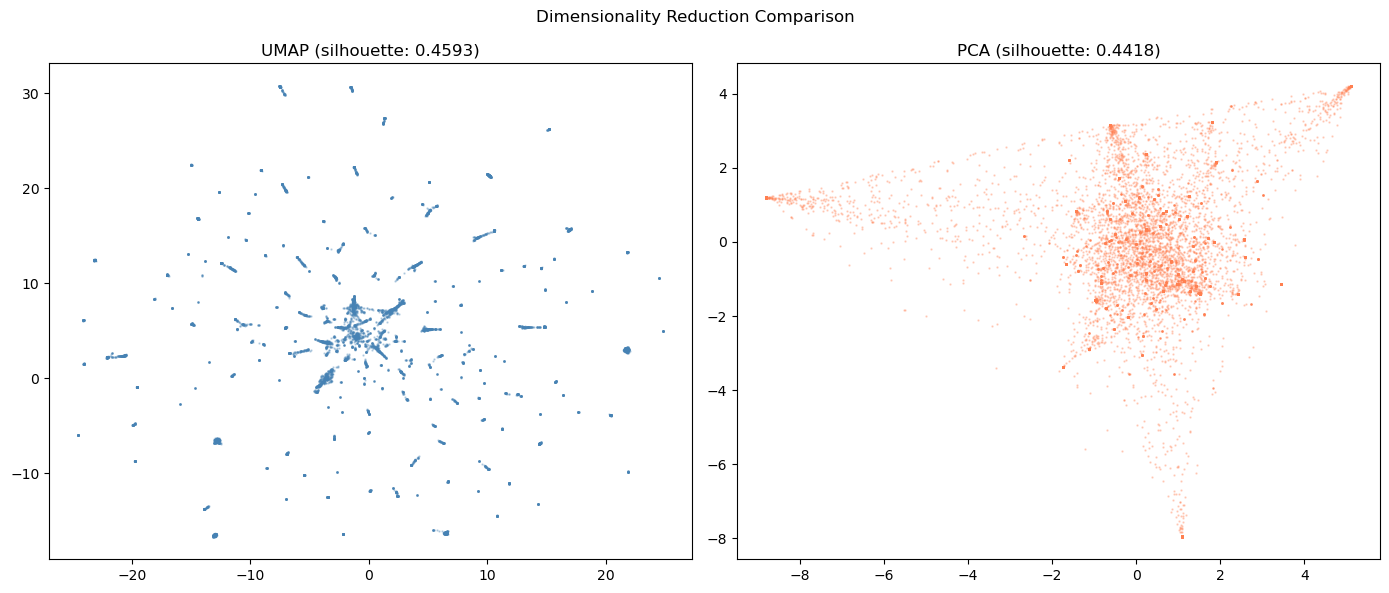

Plot saved!


In [9]:
# Silhouette scores — sample 10k for speed
from sklearn.cluster import KMeans
idx = np.random.choice(len(umap_coords), 10000, replace=False)

km_umap = KMeans(n_clusters=8, random_state=42, n_init=3).fit(umap_coords[idx])
km_pca = KMeans(n_clusters=8, random_state=42, n_init=3).fit(pca_coords[idx])

umap_score = silhouette_score(umap_coords[idx], km_umap.labels_)
pca_score = silhouette_score(pca_coords[idx], km_pca.labels_)

print(f"UMAP silhouette score: {umap_score:.4f}")
print(f"PCA  silhouette score: {pca_score:.4f}")
print(f"Winner: {'UMAP' if umap_score > pca_score else 'PCA'}")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(umap_coords[:, 0], umap_coords[:, 1], s=0.5, alpha=0.3, c='steelblue')
axes[0].set_title(f"UMAP (silhouette: {umap_score:.4f})")
axes[1].scatter(pca_coords[:, 0], pca_coords[:, 1], s=0.5, alpha=0.3, c='coral')
axes[1].set_title(f"PCA (silhouette: {pca_score:.4f})")
plt.suptitle("Dimensionality Reduction Comparison")
plt.tight_layout()
plt.savefig("../outputs/dim_reduction_comparison.png", dpi=150)
plt.show()
print("Plot saved!")

**Conclusion from Dimensionality Reduction Outputs:**\
1. **UMAP**: Shows distinct scattered clusters and points naturally group together with clear separation between groups. This indicates that customers with similar buying behaviour land near each other.
2. **PCA**: More concentrated in the centre with a long tail. There is no clear separation and makes it harder to find meaningful tribes.

The comparison between the 2 methods confirm that UMAP is the preferred method as it preserves the non-linear structure of shopping behaviour and the cluster produced are more separated, with higher silhouette score. This enables more insightful and clear analysis for the HDBSCAN in Part 8.
